# TP 2 — Data Preprocessing
**University of Biskra | Machine Learning 1 | 2025–2026**

---
> **Dataset:** Titanic (loaded via seaborn)
>
> Each exercise below is **completely independent** — run any exercise on its own.

---
# Exercise 1 — Missing Values Handling

In [2]:
# ── Exercise 1 : Missing Values Handling ─────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = sns.load_dataset('titanic')
print('=' * 60)
print('EXERCISE 1 — MISSING VALUES HANDLING')
print('=' * 60)
print(f'Dataset shape: {df.shape}')
df.head()

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# ── Q1. Count the number of missing values in each column ───────────────────
print('Q1 — Missing value count per column:')
print(df.isnull().sum())

Q1 — Missing value count per column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [ ]:
# ── Q2. Percentage of missing values per column ──────────────────────────────
print('Q2 — Missing value percentage per column:')
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0].round(2).astype(str) + ' %')

Q2 — Missing value percentage per column:
age            19.87 %
embarked        0.22 %
deck           77.22 %
embark_town     0.22 %
dtype: object


Q3 — Columns most affected by missing values:
             Missing Count  Missing %
deck                   688      77.22
age                    177      19.87
embarked                 2       0.22
embark_town              2       0.22


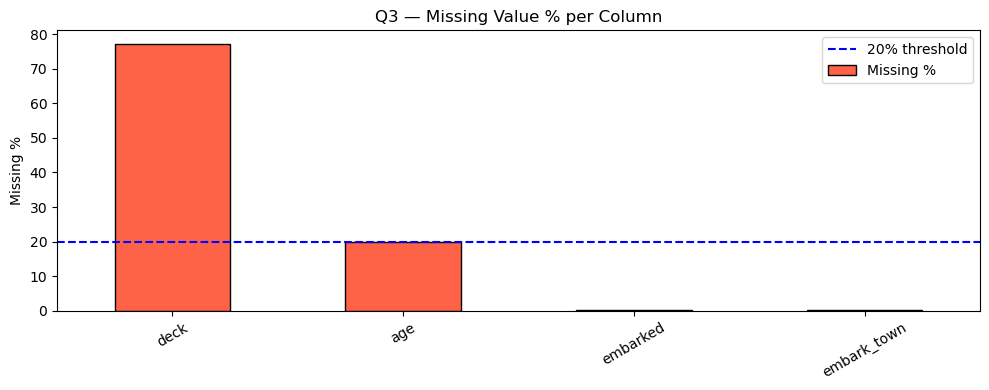

In [ ]:
# ── Q3. Identify and analyze the most affected columns ──────────────────────
print('Q3 — Columns most affected by missing values:')
affected = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     (df.isnull().sum() / len(df) * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)
print(affected)

plt.figure(figsize=(10, 4))
affected['Missing %'].plot(kind='bar', color='tomato', edgecolor='black')
plt.title('Q3 — Missing Value % per Column')
plt.ylabel('Missing %')
plt.xticks(rotation=30)
plt.axhline(20, color='blue', linestyle='--', label='20% threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Q4. Create a copy of the original dataset ────────────────────────────────
df_original = df.copy()
print('Q4 — Original dataset preserved as df_original')
print(f'Original shape: {df_original.shape}')
print(f'Total missing in original: {df_original.isnull().sum().sum()}')

Q4 — Original dataset preserved as df_original
Original shape: (891, 15)
Total missing in original: 869


In [ ]:
# ── Q5. Identify and display rows containing missing values ──────────────────
rows_with_missing = df[df.isnull().any(axis=1)]
print(f'Q5 — Rows with at least one missing value: {len(rows_with_missing)}')
rows_with_missing.head(10)

Q5 — Rows with at least one missing value: 709


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False
12,0,3,male,20.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
13,0,3,male,39.0,1,5,31.2750,S,Third,man,True,NaN,Southampton,no,False
14,0,3,female,14.0,0,0,7.8542,S,Third,child,False,NaN,Southampton,no,True


In [ ]:
# ── Q6a. Remove rows with missing values — compare size ─────────────────────
df_drop_rows = df.copy().dropna()
print('Q6a — Remove rows with missing values (dropna):')
print(f'  Before: {df.shape[0]} rows')
print(f'  After : {df_drop_rows.shape[0]} rows')
print(f'  Lost  : {df.shape[0] - df_drop_rows.shape[0]} rows ({(df.shape[0]-df_drop_rows.shape[0])/df.shape[0]*100:.1f}%)')

Q6a — Remove rows with missing values (dropna):
  Before: 891 rows
  After : 182 rows
  Lost  : 709 rows (79.6%)


In [ ]:
# ── Q6b. Remove columns with high missing % (threshold = 20%) ───────────────
threshold = 20
high_missing_cols = missing_pct[missing_pct > threshold].index.tolist()
df_drop_cols = df.copy().drop(columns=high_missing_cols)
print(f'Q6b — Remove columns with > {threshold}% missing:')
print(f'  Dropped columns: {high_missing_cols}')
print(f'  Before: {df.shape[1]} columns')
print(f'  After : {df_drop_cols.shape[1]} columns')

Q6b — Remove columns with > 20% missing:
  Dropped columns: ['deck']
  Before: 15 columns
  After : 14 columns


In [ ]:
# ── Q6c. Replace numerical missing values with mean / median / mode ─────────
df_num = df.copy()
print('Q6c — Impute numerical missing values:')
print(f'  age missing before: {df_num["age"].isnull().sum()}')

# Mean
df_mean = df_num.copy(); df_mean['age'].fillna(df_mean['age'].mean(), inplace=True)
# Median
df_median = df_num.copy(); df_median['age'].fillna(df_median['age'].median(), inplace=True)
# Mode
df_mode = df_num.copy(); df_mode['age'].fillna(df_mode['age'].mode()[0], inplace=True)

print(f'  age mean  used: {df["age"].mean():.2f}')
print(f'  age median used: {df["age"].median():.2f}')
print(f'  age mode  used: {df["age"].mode()[0]:.2f}')
print(f'  Missing after mean   imputation: {df_mean["age"].isnull().sum()}')
print(f'  Missing after median imputation: {df_median["age"].isnull().sum()}')
print(f'  Missing after mode   imputation: {df_mode["age"].isnull().sum()}')

Q6c — Impute numerical missing values:
  age missing before: 177
  age mean  used: 29.70
  age median used: 28.00
  age mode  used: 24.00
  Missing after mean   imputation: 0
  Missing after median imputation: 0
  Missing after mode   imputation: 0


In [ ]:
# ── Q6d. Replace categorical missing values with mode or 'Unknown' ───────────
df_cat = df.copy()
print('Q6d — Impute categorical missing values:')
print(f'  embarked missing before: {df_cat["embarked"].isnull().sum()}')
print(f'  deck    missing before: {df_cat["deck"].isnull().sum()}')

df_cat['embarked'].fillna(df_cat['embarked'].mode()[0], inplace=True)
df_cat['deck'] = df_cat['deck'].cat.add_categories(['Unknown'])
df_cat['deck'].fillna('Unknown', inplace=True)

print(f'  embarked missing after (mode):    {df_cat["embarked"].isnull().sum()}')
print(f'  deck    missing after (Unknown):  {df_cat["deck"].isnull().sum()}')

Q6d — Impute categorical missing values:
  embarked missing before: 2
  deck    missing before: 688
  embarked missing after (mode):    0
  deck    missing after (Unknown):  0


In [ ]:
# ── Q6e. Replace missing values with a constant — compare before/after ───────
df_const = df.copy()
print('Q6e — Fill missing values with constant (age=0, embarked=S, deck=Z):')
print('  Before:')
print(df_const[['age','embarked','deck']].isnull().sum())

df_const['age'].fillna(0, inplace=True)
df_const['embarked'].fillna('S', inplace=True)
df_const['deck'] = df_const['deck'].cat.add_categories(['Z'])
df_const['deck'].fillna('Z', inplace=True)

print('\n  After:')
print(df_const[['age','embarked','deck']].isnull().sum())
print('\n  Describe (age after constant fill):')
print(df_const['age'].describe())

Q6e — Fill missing values with constant (age=0, embarked=S, deck=Z):
  Before:
age         177
embarked      2
deck        688
dtype: int64

  After:
age         0
embarked    0
deck        0
dtype: int64

  Describe (age after constant fill):
count    891.000000
mean      23.799293
std       17.596074
min        0.000000
25%        6.000000
50%       24.000000
75%       35.000000
max       80.000000
Name: age, dtype: float64


In [ ]:
# ── Q7. Compare strategies — advantages and disadvantages ────────────────────
print('Q7 — Strategy Comparison:')
strategies = {
    'Drop Rows'    : ('Simple, no bias introduced',          'Large data loss (up to 20%+)'),
    'Drop Columns' : ('Removes noisy features',              'Loses potentially useful info'),
    'Mean Fill'    : ('Preserves distribution center',       'Sensitive to outliers'),
    'Median Fill'  : ('Robust to outliers',                  'Ignores distribution shape'),
    'Mode Fill'    : ('Works for categorical & numerical',   'Can overrepresent most frequent'),
    'Constant Fill': ('Simple, fast',                        'Introduces artificial values'),
    'Unknown Fill' : ('Keeps missingness as information',    'Creates extra category'),
}
print(f'{"Strategy":<15} {"Advantage":<45} {"Disadvantage"}')
print('-' * 90)
for k, (adv, dis) in strategies.items():
    print(f'{k:<15} {adv:<45} {dis}')

Q7 — Strategy Comparison:
Strategy        Advantage                                     Disadvantage
------------------------------------------------------------------------------------------
Drop Rows       Simple, no bias introduced                    Large data loss (up to 20%+)
Drop Columns    Removes noisy features                        Loses potentially useful info
Mean Fill       Preserves distribution center                 Sensitive to outliers
Median Fill     Robust to outliers                            Ignores distribution shape
Mode Fill       Works for categorical & numerical             Can overrepresent most frequent
Constant Fill   Simple, fast                                  Introduces artificial values
Unknown Fill    Keeps missingness as information              Creates extra category


In [ ]:
# ── Q8. Most appropriate strategy per column ─────────────────────────────────
print('Q8 — Best strategy per affected column:')
decisions = {
    'age'      : 'Median — numerical, has outliers (extreme ages)',
    'embarked' : 'Mode   — categorical, only 2 missing, dominant port (S)',
    'deck'     : '"Unknown" — 77% missing, too many to impute meaningfully',
    'embark_town': 'Mode — same as embarked, redundant column',
}
for col, decision in decisions.items():
    print(f'  {col:<15}: {decision}')

Q8 — Best strategy per affected column:
  age            : Median — numerical, has outliers (extreme ages)
  embarked       : Mode   — categorical, only 2 missing, dominant port (S)
  deck           : "Unknown" — 77% missing, too many to impute meaningfully
  embark_town    : Mode — same as embarked, redundant column


In [ ]:
# ── Q9. Apply chosen strategy and verify ─────────────────────────────────────
df_clean = df.copy()
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)
df_clean['deck'] = df_clean['deck'].cat.add_categories(['Unknown'])
df_clean['deck'].fillna('Unknown', inplace=True)

print('Q9 — Missing values after applying chosen strategies:')
remaining = df_clean.isnull().sum()
print(remaining[remaining > 0] if remaining.sum() > 0 else 'No missing values in cleaned columns!')

Q9 — Missing values after applying chosen strategies:
embark_town    2
dtype: int64


In [ ]:
# ── Q10. Compare dataset before and after cleaning ───────────────────────────
print('Q10 — Dataset Before vs After Cleaning:')
print(f'  {"Metric":<30} {"Before":>10} {"After":>10}')
print('  ' + '-' * 52)
print(f'  {"Number of Rows":<30} {df.shape[0]:>10} {df_clean.shape[0]:>10}')
print(f'  {"Number of Columns":<30} {df.shape[1]:>10} {df_clean.shape[1]:>10}')
print(f'  {"Total Missing Values":<30} {df.isnull().sum().sum():>10} {df_clean.isnull().sum().sum():>10}')
completeness_before = (1 - df.isnull().sum().sum() / df.size) * 100
completeness_after  = (1 - df_clean.isnull().sum().sum() / df_clean.size) * 100
print(f'  {"Dataset Completeness":<30} {completeness_before:>9.2f}% {completeness_after:>9.2f}%')

Q10 — Dataset Before vs After Cleaning:
  Metric                             Before      After
  ----------------------------------------------------
  Number of Rows                        891        891
  Number of Columns                      15         15
  Total Missing Values                  869          2
  Dataset Completeness               93.50%     99.99%


---
# Exercise 2 — Duplicate Data Handling

In [ ]:
# ── Exercise 2 : Duplicate Data Handling ─────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
# Artificially add duplicates so the exercise is meaningful
df = pd.concat([df, df.sample(20, random_state=42)], ignore_index=True)
print('=' * 60)
print('EXERCISE 2 — DUPLICATE DATA HANDLING')
print('=' * 60)
print(f'Dataset shape (with artificial duplicates): {df.shape}')

EXERCISE 2 — DUPLICATE DATA HANDLING
Dataset shape (with artificial duplicates): (911, 15)


In [ ]:
# ── Q1. Check whether duplicate rows exist ────────────────────────────────────
has_duplicates = df.duplicated().any()
print(f'Q1 — Duplicate rows exist: {has_duplicates}')

Q1 — Duplicate rows exist: True


In [ ]:
# ── Q2. Count duplicate rows ──────────────────────────────────────────────────
num_duplicates = df.duplicated().sum()
print(f'Q2 — Number of duplicate rows: {num_duplicates}')

Q2 — Number of duplicate rows: 127


In [ ]:
# ── Q3. Display duplicate rows ────────────────────────────────────────────────
dup_rows = df[df.duplicated(keep=False)]
print(f'Q3 — All duplicate rows (showing both copies): {len(dup_rows)} rows')
dup_rows.head(10)

Q3 — All duplicate rows (showing both copies): 195 rows


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True
29,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
32,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
37,0,3,male,21.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
39,1,3,female,14.0,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False
42,0,3,male,NaN,0,0,7.8958,C,Third,man,True,NaN,Cherbourg,no,True
45,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
46,0,3,male,NaN,1,0,15.5000,Q,Third,man,True,NaN,Queenstown,no,False


In [ ]:
# ── Q4. Remove duplicate rows ─────────────────────────────────────────────────
df_no_dup = df.drop_duplicates()
print(f'Q4 — Duplicates removed using drop_duplicates()')

Q4 — Duplicates removed using drop_duplicates()


In [ ]:
# ── Q5. Verify size before and after ─────────────────────────────────────────
print(f'Q5 — Size before removal: {df.shape[0]} rows')
print(f'     Size after  removal: {df_no_dup.shape[0]} rows')
print(f'     Removed: {df.shape[0] - df_no_dup.shape[0]} rows')

Q5 — Size before removal: 911 rows
     Size after  removal: 784 rows
     Removed: 127 rows


In [ ]:
# ── Q6. Confirm no duplicates remain ─────────────────────────────────────────
remaining_dup = df_no_dup.duplicated().sum()
print(f'Q6 — Duplicate rows remaining after cleaning: {remaining_dup}')

Q6 — Duplicate rows remaining after cleaning: 0


Q7 — Comparison Before vs After Duplicate Removal:
  Metric                        Before      After
  -----------------------------------------------
  Number of Rows                   911        784
  Fare Std (consistency)        49.248     52.160

  Class distribution (survived):
  Before:
survived
0    61.36 %
1    38.64 %
Name: proportion, dtype: object
  After:
survived
0    58.8 %
1    41.2 %
Name: proportion, dtype: object


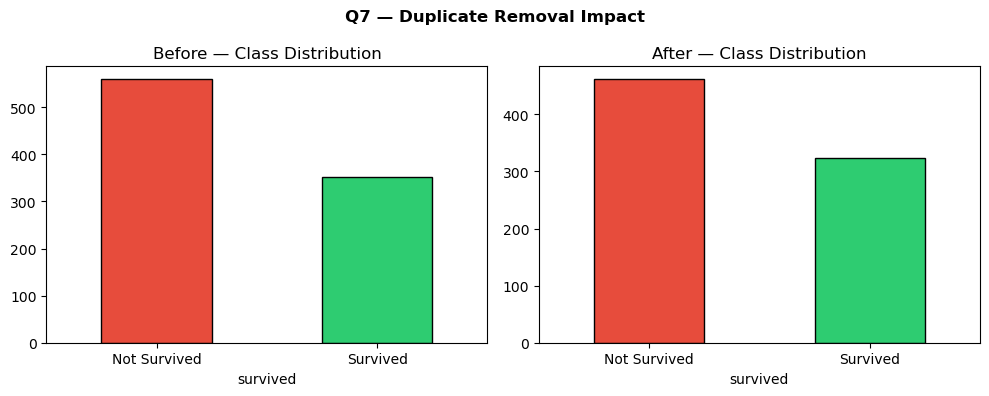

In [ ]:
# ── Q7. Compare before and after ─────────────────────────────────────────────
print('Q7 — Comparison Before vs After Duplicate Removal:')
print(f'  {"Metric":<25} {"Before":>10} {"After":>10}')
print('  ' + '-' * 47)
print(f'  {"Number of Rows":<25} {df.shape[0]:>10} {df_no_dup.shape[0]:>10}')

# Data consistency — std of numerical columns
std_before = df['fare'].std()
std_after  = df_no_dup['fare'].std()
print(f'  {"Fare Std (consistency)":<25} {std_before:>10.3f} {std_after:>10.3f}')

# Class distribution
print('\n  Class distribution (survived):')
print('  Before:')
print((df['survived'].value_counts(normalize=True) * 100).round(2).astype(str) + ' %')
print('  After:')
print((df_no_dup['survived'].value_counts(normalize=True) * 100).round(2).astype(str) + ' %')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Before — Class Distribution')
axes[0].set_xticklabels(['Not Survived','Survived'], rotation=0)
df_no_dup['survived'].value_counts().plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[1].set_title('After — Class Distribution')
axes[1].set_xticklabels(['Not Survived','Survived'], rotation=0)
plt.suptitle('Q7 — Duplicate Removal Impact', fontweight='bold')
plt.tight_layout()
plt.show()

---
# Exercise 3 — Outlier Detection and Treatment

In [ ]:
# ── Exercise 3 : Outlier Detection and Treatment ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
num_cols = ['age', 'fare', 'sibsp', 'parch']
df_num = df[num_cols].copy()

print('=' * 60)
print('EXERCISE 3 — OUTLIER DETECTION AND TREATMENT')
print('=' * 60)
df_num.describe()

EXERCISE 3 — OUTLIER DETECTION AND TREATMENT


,age,fare,sibsp,parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [ ]:
# ── Q1. Statistical summaries to identify potential outliers ─────────────────
print('Q1 — Statistical summary (describe + quantiles):')
print(df_num.describe())
print('\nQuantiles (1%, 5%, 95%, 99%):')
print(df_num.quantile([0.01, 0.05, 0.95, 0.99]))

Q1 — Statistical summary (describe + quantiles):
              age        fare       sibsp       parch
count  714.000000  891.000000  891.000000  891.000000
mean    29.699118   32.204208    0.523008    0.381594
std     14.526497   49.693429    1.102743    0.806057
min      0.420000    0.000000    0.000000    0.000000
25%     20.125000    7.910400    0.000000    0.000000
50%     28.000000   14.454200    0.000000    0.000000
75%     38.000000   31.000000    1.000000    0.000000
max     80.000000  512.329200    8.000000    6.000000

Quantiles (1%, 5%, 95%, 99%):
        age       fare  sibsp  parch
0.01   1.00    0.00000    0.0    0.0
0.05   4.00    7.22500    0.0    0.0
0.95  56.00  112.07915    3.0    2.0
0.99  65.87  249.00622    5.0    4.0


In [ ]:
# ── Q2. IQR Method ───────────────────────────────────────────────────────────
print('Q2 — IQR Outlier Detection:')
iqr_results = {}
for col in num_cols:
    col_data = df_num[col].dropna()
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = col_data[(col_data < lower) | (col_data > upper)]
    iqr_results[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                        'Lower': lower, 'Upper': upper, 'Count': len(outliers)}
    print(f'  {col:<8}: Q1={Q1:.2f} Q3={Q3:.2f} IQR={IQR:.2f} '
          f'Bounds=[{lower:.2f}, {upper:.2f}] Outliers={len(outliers)}')

Q2 — IQR Outlier Detection:
  age     : Q1=20.12 Q3=38.00 IQR=17.88 Bounds=[-6.69, 64.81] Outliers=11
  fare    : Q1=7.91 Q3=31.00 IQR=23.09 Bounds=[-26.72, 65.63] Outliers=116
  sibsp   : Q1=0.00 Q3=1.00 IQR=1.00 Bounds=[-1.50, 2.50] Outliers=46
  parch   : Q1=0.00 Q3=0.00 IQR=0.00 Bounds=[0.00, 0.00] Outliers=213


In [ ]:
# ── Q3. Z-score Method ───────────────────────────────────────────────────────
from scipy import stats
print('Q3 — Z-score Outlier Detection (|Z| > 3):')
for col in num_cols:
    col_data = df_num[col].dropna()
    z_scores = np.abs(stats.zscore(col_data))
    outliers_z = col_data[z_scores > 3]
    print(f'  {col:<8}: {len(outliers_z)} outliers (|Z| > 3)')

Q3 — Z-score Outlier Detection (|Z| > 3):
  age     : 2 outliers (|Z| > 3)
  fare    : 20 outliers (|Z| > 3)
  sibsp   : 30 outliers (|Z| > 3)
  parch   : 15 outliers (|Z| > 3)


Q4 — Visualizing outliers (boxplot + histogram + scatter):


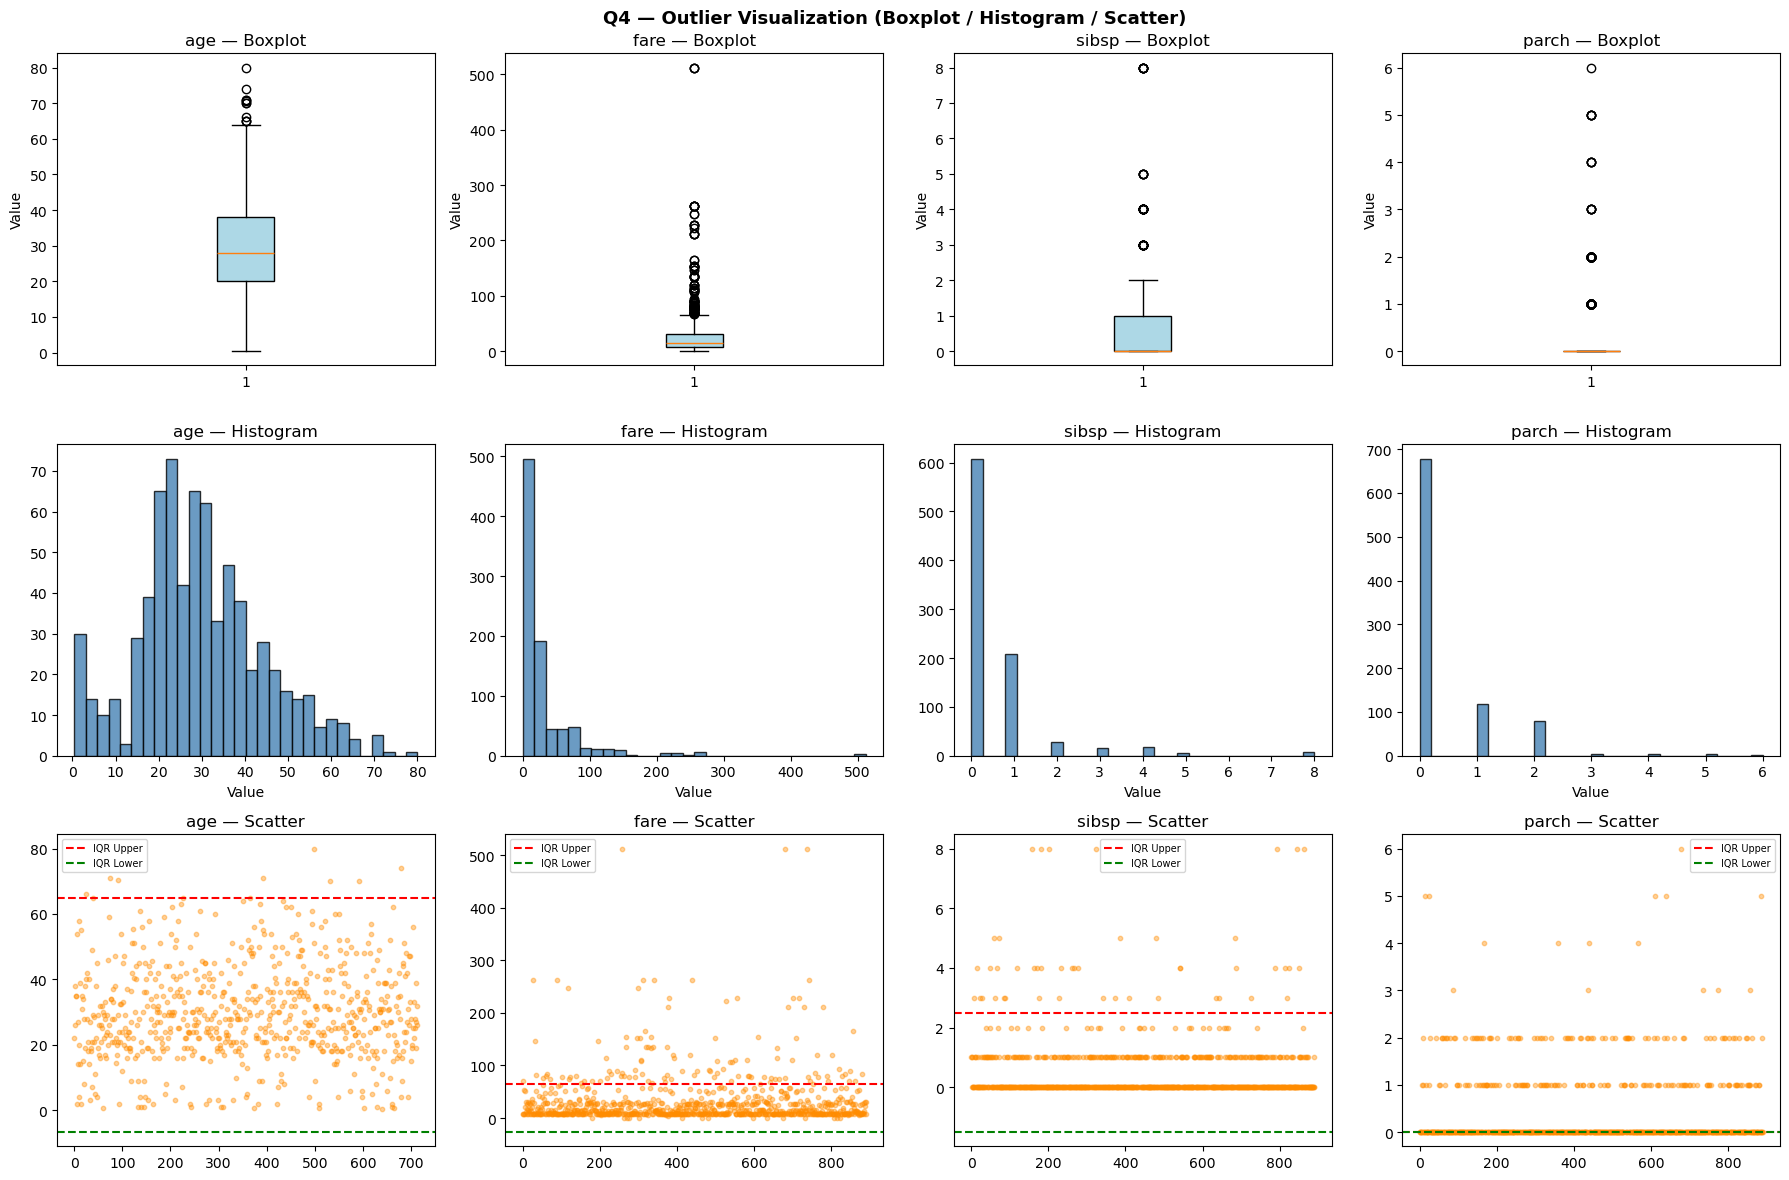

In [ ]:
# ── Q4. Visualize outliers ────────────────────────────────────────────────────
print('Q4 — Visualizing outliers (boxplot + histogram + scatter):')
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for i, col in enumerate(num_cols):
    data = df_num[col].dropna()

    # Boxplot
    axes[0, i].boxplot(data, patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[0, i].set_title(f'{col} — Boxplot')
    axes[0, i].set_ylabel('Value')

    # Histogram
    axes[1, i].hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    axes[1, i].set_title(f'{col} — Histogram')
    axes[1, i].set_xlabel('Value')

    # Scatter (index vs value)
    axes[2, i].scatter(range(len(data)), data, alpha=0.4, color='darkorange', s=10)
    r = iqr_results[col]
    axes[2, i].axhline(r['Upper'], color='red', linestyle='--', label='IQR Upper')
    axes[2, i].axhline(r['Lower'], color='green', linestyle='--', label='IQR Lower')
    axes[2, i].set_title(f'{col} — Scatter')
    axes[2, i].legend(fontsize=7)

plt.suptitle('Q4 — Outlier Visualization (Boxplot / Histogram / Scatter)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Q5. Extreme min and max values ───────────────────────────────────────────
print('Q5 — Extreme min and max values:')
for col in num_cols:
    print(f'  {col:<8}: min={df_num[col].min():.2f}  max={df_num[col].max():.2f}')

Q5 — Extreme min and max values:
  age     : min=0.42  max=80.00
  fare    : min=0.00  max=512.33
  sibsp   : min=0.00  max=8.00
  parch   : min=0.00  max=6.00


In [ ]:
# ── Q6. Count detected outliers (IQR method) ─────────────────────────────────
print('Q6 — Outlier count per column (IQR method):')
outlier_mask = pd.Series([False] * len(df_num), index=df_num.index)
for col in num_cols:
    r = iqr_results[col]
    col_mask = (df_num[col] < r['Lower']) | (df_num[col] > r['Upper'])
    print(f'  {col:<8}: {col_mask.sum()} outliers')
    outlier_mask = outlier_mask | col_mask

total_outlier_rows = outlier_mask.sum()
print(f'\n  Total rows with at least one outlier: {total_outlier_rows}')

Q6 — Outlier count per column (IQR method):
  age     : 11 outliers
  fare    : 116 outliers
  sibsp   : 46 outliers
  parch   : 213 outliers

  Total rows with at least one outlier: 293


In [ ]:
# ── Q7. Remove outliers — compare before and after ───────────────────────────
df_no_out = df.copy()
mask_keep = pd.Series([True] * len(df_no_out), index=df_no_out.index)
for col in num_cols:
    r = iqr_results[col]
    col_clean = ~((df_no_out[col] < r['Lower']) | (df_no_out[col] > r['Upper']))
    mask_keep = mask_keep & col_clean
df_no_out = df_no_out[mask_keep]

print('Q7 — Remove outliers:')
print(f'  Before: {df.shape[0]} rows')
print(f'  After : {df_no_out.shape[0]} rows')
print(f'  Removed: {df.shape[0] - df_no_out.shape[0]} rows')

Q7 — Remove outliers:
  Before: 891 rows
  After : 598 rows
  Removed: 293 rows


In [ ]:
# ── Q8. Capping (Winsorization) and Log Transformation ───────────────────────
print('Q8 — Alternative strategies: Capping and Log Transformation:')

df_capped = df.copy()
for col in num_cols:
    r = iqr_results[col]
    df_capped[col] = df_capped[col].clip(lower=r['Lower'], upper=r['Upper'])
print('  Capping applied (clip to IQR bounds):')
print(f'    fare max before: {df["fare"].max():.2f}  after: {df_capped["fare"].max():.2f}')

df_log = df.copy()
df_log['fare_log'] = np.log1p(df_log['fare'])
print(f'  Log transform applied (log1p) to fare:')
print(f'    fare     — skewness: {df["fare"].skew():.3f}')
print(f'    fare_log — skewness: {df_log["fare_log"].skew():.3f}')

Q8 — Alternative strategies: Capping and Log Transformation:
  Capping applied (clip to IQR bounds):
    fare max before: 512.33  after: 65.63
  Log transform applied (log1p) to fare:
    fare     — skewness: 4.787
    fare_log — skewness: 0.395


In [ ]:
# ── Q9. Compare statistics before and after treatment ────────────────────────
print('Q9 — Statistics before and after outlier treatment (fare):')
compare = pd.DataFrame({
    'Original':    df['fare'].describe(),
    'Removed':     df_no_out['fare'].describe(),
    'Capped':      df_capped['fare'].describe(),
}).round(3)
print(compare)

Q9 — Statistics before and after outlier treatment (fare):
       Original  Removed   Capped
count   891.000  598.000  891.000
mean     32.204   15.146   24.047
std      49.693   12.571   20.482
min       0.000    0.000    0.000
25%       7.910    7.778    7.910
50%      14.454    8.698   14.454
75%      31.000   16.100   31.000
max     512.329   61.175   65.634


In [ ]:
# ── Q10. Discussion ──────────────────────────────────────────────────────────
print("""Q10 — Discussion:

• Impact on mean and std:
  Outliers inflate the mean and standard deviation significantly.
  For 'fare', the max is 512 while the median is only 14 — a single
  extreme value can shift the mean by several units.

• When to REMOVE outliers:
  - When they result from data entry errors or measurement errors.
  - When the model is sensitive to extreme values (e.g., Linear Regression, KNN).
  - When the dataset is large enough to afford losing rows.

• When to PRESERVE outliers:
  - When they represent genuine rare but important events.
  - Example: high fare passengers are 1st class — removing them loses signal.
  - Fraud detection: the outlier IS the fraud.
  - Tree-based models (Random Forest, Decision Tree) are robust to outliers.

• Effect on ML models:
  - Linear/Logistic Regression: heavily affected — outliers pull the decision boundary.
  - KNN: affected because distances are distorted by extreme values.
  - SVM: sensitive to outliers in the margin.
  - Decision Tree / Random Forest: relatively robust.
  - Best practice: scale + cap outliers before distance-based models.""")

Q10 — Discussion:

• Impact on mean and std:
  Outliers inflate the mean and standard deviation significantly.
  For 'fare', the max is 512 while the median is only 14 — a single
  extreme value can shift the mean by several units.

• When to REMOVE outliers:
  - When they result from data entry errors or measurement errors.
  - When the model is sensitive to extreme values (e.g., Linear Regression, KNN).
  - When the dataset is large enough to afford losing rows.

• When to PRESERVE outliers:
  - When they represent genuine rare but important events.
  - Example: high fare passengers are 1st class — removing them loses signal.
  - Fraud detection: the outlier IS the fraud.
  - Tree-based models (Random Forest, Decision Tree) are robust to outliers.

• Effect on ML models:
  - Linear/Logistic Regression: heavily affected — outliers pull the decision boundary.
  - KNN: affected because distances are distorted by extreme values.
  - SVM: sensitive to outliers in the margin.
  - Decision 

---
# Exercise 4 — Data Type and Consistency Checking

In [ ]:
# ── Exercise 4 : Data Type and Consistency Checking ───────────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')

# Inject inconsistencies to make the exercise realistic
df_dirty = df.copy()
df_dirty.loc[0:5,  'sex']      = df_dirty.loc[0:5, 'sex'].str.upper()
df_dirty.loc[6:10, 'embarked'] = df_dirty.loc[6:10, 'embarked'].str.lower() + ' '
df_dirty['pclass'] = df_dirty['pclass'].astype(str)  # wrongly stored as string
df_dirty['survived'] = df_dirty['survived'].astype(str)

print('=' * 60)
print('EXERCISE 4 — DATA TYPE AND CONSISTENCY CHECKING')
print('=' * 60)

EXERCISE 4 — DATA TYPE AND CONSISTENCY CHECKING


In [ ]:
# ── Q1. Display and analyze data types ───────────────────────────────────────
print('Q1 — Data types of each column:')
print(df_dirty.dtypes)
print(f'\nDataset shape: {df_dirty.shape}')

Q1 — Data types of each column:
survived         object
pclass           object
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Dataset shape: (891, 15)


In [ ]:
# ── Q2. Identify inappropriate or inconsistent types ─────────────────────────
print('Q2 — Inappropriate/Inconsistent data types identified:')
print('  pclass   : should be int, currently:', df_dirty['pclass'].dtype)
print('  survived : should be int, currently:', df_dirty['survived'].dtype)
print('  sex      : has inconsistent casing:', df_dirty['sex'].unique())
print('  embarked : has trailing spaces:', [repr(v) for v in df_dirty['embarked'].dropna().unique()[:6]])

Q2 — Inappropriate/Inconsistent data types identified:
  pclass   : should be int, currently: object
  survived : should be int, currently: object
  sex      : has inconsistent casing: ['MALE' 'FEMALE' 'male' 'female']
  embarked : has trailing spaces: ["'S'", "'C'", "'Q'", "'s '", "'c '"]


In [ ]:
# ── Q3. Convert columns to appropriate formats ───────────────────────────────
df_fixed = df_dirty.copy()
df_fixed['pclass']   = df_fixed['pclass'].astype(int)
df_fixed['survived'] = df_fixed['survived'].astype(int)
print('Q3 — Converted pclass and survived to int:')
print('  pclass  dtype:', df_fixed['pclass'].dtype)
print('  survived dtype:', df_fixed['survived'].dtype)

Q3 — Converted pclass and survived to int:
  pclass  dtype: int64
  survived dtype: int64


In [ ]:
# ── Q4. Detect inconsistent categorical values ────────────────────────────────
print('Q4 — Unique values BEFORE standardization:')
print('  sex unique values     :', df_fixed['sex'].unique())
print('  embarked unique values:', df_fixed['embarked'].dropna().unique())

Q4 — Unique values BEFORE standardization:
  sex unique values     : ['MALE' 'FEMALE' 'male' 'female']
  embarked unique values: ['S' 'C' 'Q' 's ' 'c ']


In [ ]:
# ── Q5. Standardize categorical formats ──────────────────────────────────────
df_fixed['sex']      = df_fixed['sex'].str.lower().str.strip()
df_fixed['embarked'] = df_fixed['embarked'].str.upper().str.strip()
print('Q5 — Unique values AFTER standardization:')
print('  sex unique values     :', df_fixed['sex'].unique())
print('  embarked unique values:', df_fixed['embarked'].dropna().unique())

print('\n  Summary of type corrections:')
print(df_fixed.dtypes)

Q5 — Unique values AFTER standardization:
  sex unique values     : ['male' 'female']
  embarked unique values: ['S' 'C' 'Q']

  Summary of type corrections:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [ ]:
# ── Q6. Why correct data types are critical for modeling ─────────────────────
print("""Q6 — Why correct data types are critical for modeling:

  1. ML algorithms operate on numerical values. If 'pclass' is stored
     as a string ('1','2','3'), it cannot be used in arithmetic or fed
     directly to sklearn estimators without conversion.

  2. Inconsistent casing ('Male' vs 'male') causes them to be treated
     as different categories, doubling the number of encoded features
     and introducing noise.

  3. Trailing spaces (' S' vs 'S') lead to incorrect grouping in
     value_counts(), groupby(), and encoders — making imputation wrong.

  4. A boolean stored as object (string 'True'/'False') cannot be used
     in logical operations or aggregations without explicit conversion.

  5. Date columns stored as strings cannot be sorted, subtracted, or
     used for time-based feature engineering.

  Conclusion: Type checking is the first mandatory step before any
  preprocessing, encoding, or modeling.""")

Q6 — Why correct data types are critical for modeling:

  1. ML algorithms operate on numerical values. If 'pclass' is stored
     as a string ('1','2','3'), it cannot be used in arithmetic or fed
     directly to sklearn estimators without conversion.

  2. Inconsistent casing ('Male' vs 'male') causes them to be treated
     as different categories, doubling the number of encoded features
     and introducing noise.

  3. Trailing spaces (' S' vs 'S') lead to incorrect grouping in
     value_counts(), groupby(), and encoders — making imputation wrong.

  4. A boolean stored as object (string 'True'/'False') cannot be used
     in logical operations or aggregations without explicit conversion.

  5. Date columns stored as strings cannot be sorted, subtracted, or
     used for time-based feature engineering.

  Conclusion: Type checking is the first mandatory step before any
  preprocessing, encoding, or modeling.


---
# Exercise 5 — Class Imbalance Analysis

In [ ]:
# ── Exercise 5 : Class Imbalance Analysis ─────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
# Preprocess minimally for balancing to work
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df.drop(columns=['deck','embark_town','alive','who','adult_male','alone','class'], inplace=True)
from sklearn.preprocessing import LabelEncoder
df['sex']      = LabelEncoder().fit_transform(df['sex'])
df['embarked'] = LabelEncoder().fit_transform(df['embarked'].astype(str))

print('=' * 60)
print('EXERCISE 5 — CLASS IMBALANCE ANALYSIS')
print('=' * 60)
print(f'Dataset shape: {df.shape}')

EXERCISE 5 — CLASS IMBALANCE ANALYSIS
Dataset shape: (891, 8)


In [ ]:
# ── Q1. Analyze the distribution of the target variable ──────────────────────
print('Q1 — Target variable distribution (survived):')
print(df['survived'].value_counts())

Q1 — Target variable distribution (survived):
survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
# ── Q2. Compute class proportions ─────────────────────────────────────────────
print('Q2 — Class proportions:')
proportions = df['survived'].value_counts(normalize=True) * 100
print(proportions.round(2).astype(str) + ' %')
ratio = df['survived'].value_counts()[0] / df['survived'].value_counts()[1]
print(f'  Imbalance ratio (0:1): {ratio:.2f}:1')

Q2 — Class proportions:
survived
0    61.62 %
1    38.38 %
Name: proportion, dtype: object
  Imbalance ratio (0:1): 1.61:1


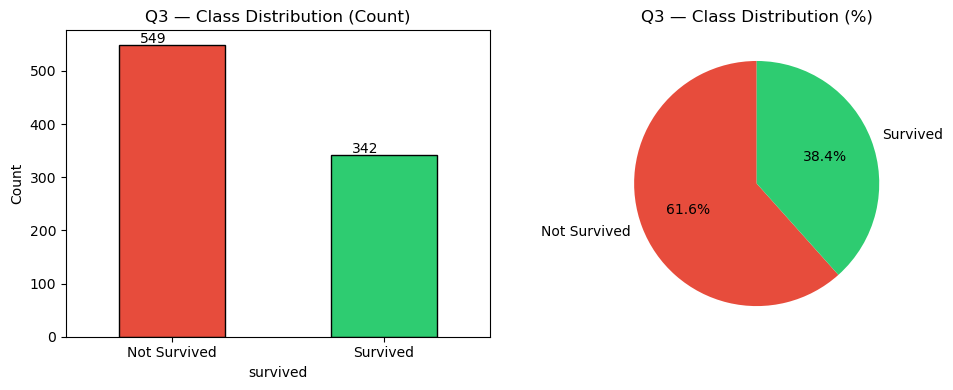

In [ ]:
# ── Q3. Visualize class distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df['survived'].value_counts()
counts.plot(kind='bar', ax=axes[0], color=['#e74c3c','#2ecc71'], edgecolor='black')
axes[0].set_title('Q3 — Class Distribution (Count)')
axes[0].set_xticklabels(['Not Survived','Survived'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(str(p.get_height()), (p.get_x()+0.1, p.get_height()+3))

counts.plot(kind='pie', ax=axes[1], labels=['Not Survived','Survived'],
            colors=['#e74c3c','#2ecc71'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Q3 — Class Distribution (%)')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# ── Q4. Determine whether the dataset is balanced ────────────────────────────
min_prop = proportions.min()
is_balanced = min_prop >= 40
print(f'Q4 — Is the dataset balanced? {"YES" if is_balanced else "NO"}')
print(f'  Minority class proportion: {min_prop:.2f}% (balanced if >= 40%)')
print(f'  The dataset is MODERATELY imbalanced (38.4% vs 61.6%).')

Q4 — Is the dataset balanced? NO
  Minority class proportion: 38.38% (balanced if >= 40%)
  The dataset is MODERATELY imbalanced (38.4% vs 61.6%).


In [ ]:
# ── Q5. Discussion — imbalance risks and alternative metrics ─────────────────
print("""Q5 — Risks and Alternatives:

  Risk of using Accuracy as sole metric:
    A model that always predicts class 0 (Not Survived) achieves
    61.6% accuracy without learning anything meaningful.
    This is called the 'accuracy paradox'.

  Alternative metrics for imbalanced data:
    • Precision  — of all predicted positives, how many are correct?
    • Recall     — of all actual positives, how many did we catch?
    • F1-Score   — harmonic mean of Precision and Recall.
    • ROC-AUC    — measures separability across all thresholds.
    • PR-AUC     — Precision-Recall curve, better for severe imbalance.""")

Q5 — Risks and Alternatives:

  Risk of using Accuracy as sole metric:
    A model that always predicts class 0 (Not Survived) achieves
    61.6% accuracy without learning anything meaningful.
    This is called the 'accuracy paradox'.

  Alternative metrics for imbalanced data:
    • Precision  — of all predicted positives, how many are correct?
    • Recall     — of all actual positives, how many did we catch?
    • F1-Score   — harmonic mean of Precision and Recall.
    • ROC-AUC    — measures separability across all thresholds.
    • PR-AUC     — Precision-Recall curve, better for severe imbalance.


In [ ]:
# ── Q6. Apply balancing techniques ───────────────────────────────────────────
from sklearn.utils import resample

X = df.drop(columns=['survived'])
y = df['survived']

df_majority = df[df['survived'] == 0]
df_minority = df[df['survived'] == 1]

# Random Undersampling
df_major_under = resample(df_majority, replace=False,
                          n_samples=len(df_minority), random_state=42)
df_under = pd.concat([df_major_under, df_minority])

# Random Oversampling
df_minor_over = resample(df_minority, replace=True,
                         n_samples=len(df_majority), random_state=42)
df_over = pd.concat([df_majority, df_minor_over])

# SMOTE
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_sm, y_sm = smote.fit_resample(X, y)
    smote_counts = pd.Series(y_sm).value_counts()
    smote_available = True
except ImportError:
    smote_available = False
    print('  Note: imbalanced-learn not installed. Skipping SMOTE.')
    print('  Install with: !pip install imbalanced-learn')

print('Q6 — Balancing Techniques Applied:')
print(f'  Original          : {df["survived"].value_counts().to_dict()}')
print(f'  Undersampling     : {df_under["survived"].value_counts().to_dict()}')
print(f'  Oversampling      : {df_over["survived"].value_counts().to_dict()}')
if smote_available:
    print(f'  SMOTE             : {smote_counts.to_dict()}')

Q6 — Balancing Techniques Applied:
  Original          : {0: 549, 1: 342}
  Undersampling     : {0: 342, 1: 342}
  Oversampling      : {0: 549, 1: 549}
  SMOTE             : {0: 549, 1: 549}


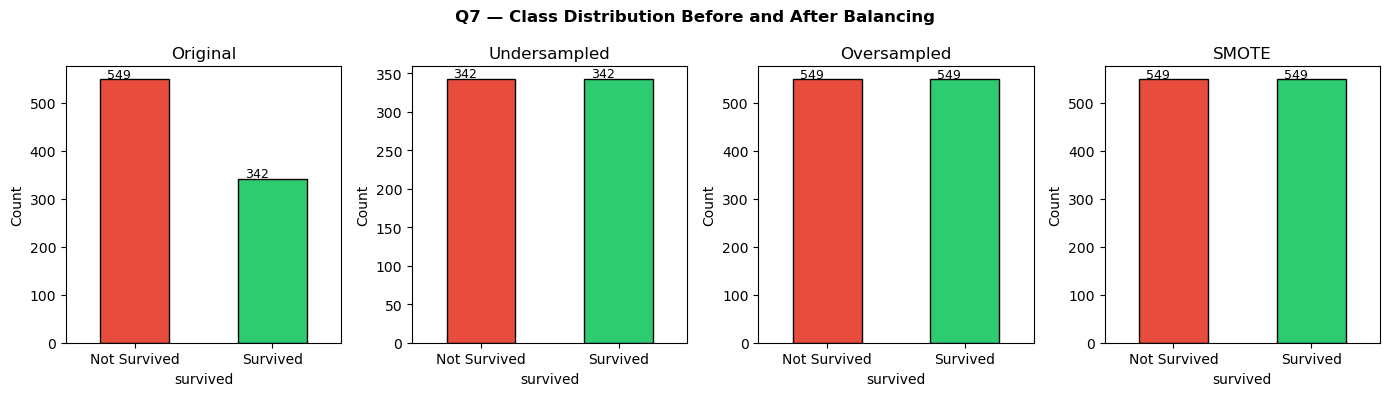

In [ ]:
# ── Q7. Compare class distribution before and after balancing ────────────────
labels = ['Not Survived', 'Survived']
datasets = {
    'Original':     df['survived'].value_counts().sort_index(),
    'Undersampled': df_under['survived'].value_counts().sort_index(),
    'Oversampled':  df_over['survived'].value_counts().sort_index(),
}
if smote_available:
    datasets['SMOTE'] = pd.Series(y_sm).value_counts().sort_index()

fig, axes = plt.subplots(1, len(datasets), figsize=(14, 4))
colors = ['#e74c3c', '#2ecc71']
for ax, (title, counts) in zip(axes, datasets.items()):
    counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
    ax.set_title(title)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylabel('Count')
    for p in ax.patches:
        ax.annotate(str(p.get_height()), (p.get_x()+0.05, p.get_height()+3), fontsize=9)
plt.suptitle('Q7 — Class Distribution Before and After Balancing', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Q8. Advantages and limitations ───────────────────────────────────────────
print("""Q8 — Advantages and Limitations:

  Random Undersampling:
    ✅ Simple, fast, reduces training time
    ❌ Loses information from the majority class
    ❌ May remove important borderline samples

  Random Oversampling:
    ✅ No information loss
    ❌ Creates exact duplicate rows → risk of overfitting
    ❌ Increases training time

  SMOTE (Synthetic Minority Oversampling Technique):
    ✅ Generates synthetic (not duplicate) minority samples
    ✅ More robust than simple oversampling
    ❌ Can introduce noise if minority class is very spread
    ❌ Not suitable for categorical features directly""")

Q8 — Advantages and Limitations:

  Random Undersampling:
    ✅ Simple, fast, reduces training time
    ❌ Loses information from the majority class
    ❌ May remove important borderline samples

  Random Oversampling:
    ✅ No information loss
    ❌ Creates exact duplicate rows → risk of overfitting
    ❌ Increases training time

  SMOTE (Synthetic Minority Oversampling Technique):
    ✅ Generates synthetic (not duplicate) minority samples
    ✅ More robust than simple oversampling
    ❌ Can introduce noise if minority class is very spread
    ❌ Not suitable for categorical features directly


---
# Exercise 6 — Feature Encoding

In [ ]:
# ── Exercise 6 : Feature Encoding ────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder

df = sns.load_dataset('titanic')
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df['deck'] = df['deck'].cat.add_categories(['Unknown'])
df['deck'].fillna('Unknown', inplace=True)

print('=' * 60)
print('EXERCISE 6 — FEATURE ENCODING')
print('=' * 60)

EXERCISE 6 — FEATURE ENCODING


In [ ]:
# ── Q1. Identify categorical variables ───────────────────────────────────────
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Q1 — Categorical columns identified:')
for col in cat_cols:
    print(f'  {col:<15}: {df[col].nunique()} unique values → {df[col].unique()[:5]}')

Q1 — Categorical columns identified:
  sex            : 2 unique values → ['male' 'female']
  embarked       : 3 unique values → ['S' 'C' 'Q']
  class          : 3 unique values → ['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']
  who            : 3 unique values → ['man' 'woman' 'child']
  deck           : 8 unique values → ['Unknown', 'C', 'E', 'G', 'D']
Categories (8, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Unknown']
  embark_town    : 3 unique values → ['Southampton' 'Cherbourg' 'Queenstown' nan]
  alive          : 2 unique values → ['no' 'yes']


In [ ]:
# ── Q2a. Label Encoding ───────────────────────────────────────────────────────
df_label = df.copy()
le = LabelEncoder()
label_map = {}
print('Q2a — Label Encoding:')
for col in cat_cols:
    df_label[col] = le.fit_transform(df_label[col].astype(str))
    label_map[col] = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  {col:<15}: {label_map[col]}')

print(f'\n  Shape after Label Encoding: {df_label.shape}')
df_label.head(3)

Q2a — Label Encoding:
  sex            : {'female': np.int64(0), 'male': np.int64(1)}
  embarked       : {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}
  class          : {'First': np.int64(0), 'Second': np.int64(1), 'Third': np.int64(2)}
  who            : {'child': np.int64(0), 'man': np.int64(1), 'woman': np.int64(2)}
  deck           : {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4), 'F': np.int64(5), 'G': np.int64(6), 'Unknown': np.int64(7)}
  embark_town    : {'Cherbourg': np.int64(0), 'Queenstown': np.int64(1), 'Southampton': np.int64(2), 'nan': np.int64(3)}
  alive          : {'no': np.int64(0), 'yes': np.int64(1)}

  Shape after Label Encoding: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,7,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,2,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,7,2,1,True


In [ ]:
# ── Q2b. One-Hot Encoding ─────────────────────────────────────────────────────
df_ohe = df.copy()
df_ohe = pd.get_dummies(df_ohe, columns=cat_cols, drop_first=False)
print('Q2b — One-Hot Encoding:')
print(f'  Shape after OHE: {df_ohe.shape}')
print(f'  New columns added: {df_ohe.shape[1] - df.shape[1]}')
ohe_cols = [c for c in df_ohe.columns if any(c.startswith(cat+'_') for cat in cat_cols)]
print(f'  OHE columns sample: {ohe_cols[:8]}')
df_ohe.head(3)

Q2b — One-Hot Encoding:
  Shape after OHE: (891, 32)
  New columns added: 17
  OHE columns sample: ['sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'class_First', 'class_Second', 'class_Third']


,survived,pclass,age,sibsp,parch,fare,adult_male,alone,sex_female,sex_male,...,deck_D,deck_E,deck_F,deck_G,deck_Unknown,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,alive_no,alive_yes
0,0,3,22.0,1,0,7.2500,True,False,False,True,...,False,False,False,False,True,False,False,True,True,False
1,1,1,38.0,1,0,71.2833,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
2,1,3,26.0,0,0,7.9250,False,True,True,False,...,False,False,False,False,True,False,False,True,False,True


Q3 — Dimensionality Comparison:
  Dataset                     Rows    Columns
  -------------------------------------------
  Original                     891         15
  Label Encoded                891         15
  One-Hot Encoded              891         32


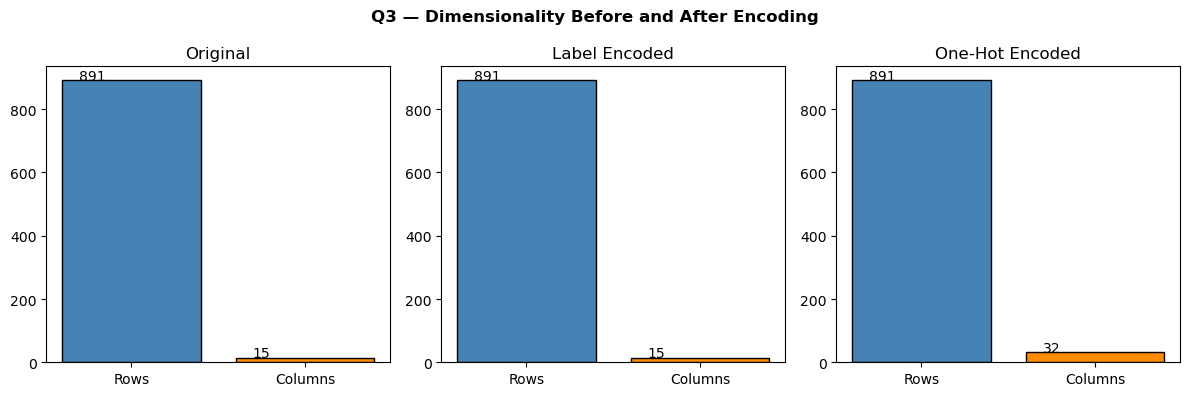

In [ ]:
# ── Q3. Compare dimensionality before and after encoding ─────────────────────
print('Q3 — Dimensionality Comparison:')
print(f'  {"Dataset":<25} {"Rows":>6} {"Columns":>10}')
print('  ' + '-' * 43)
print(f'  {"Original":<25} {df.shape[0]:>6} {df.shape[1]:>10}')
print(f'  {"Label Encoded":<25} {df_label.shape[0]:>6} {df_label.shape[1]:>10}')
print(f'  {"One-Hot Encoded":<25} {df_ohe.shape[0]:>6} {df_ohe.shape[1]:>10}')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, shape) in zip(axes, [
    ('Original', df.shape),
    ('Label Encoded', df_label.shape),
    ('One-Hot Encoded', df_ohe.shape)
]):
    ax.bar(['Rows','Columns'], [shape[0], shape[1]],
           color=['steelblue','darkorange'], edgecolor='black')
    ax.set_title(name)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())), (p.get_x()+0.1, p.get_height()+0.5))
plt.suptitle('Q3 — Dimensionality Before and After Encoding', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Q4. When to use each encoding technique ───────────────────────────────────
print("""Q4 — When to use each encoding technique:

  Label Encoding:
    ✅ Use for ORDINAL categories where order matters:
       e.g., deck (A < B < C ... G), age_group (Child < Teen < Adult)
    ✅ Efficient (no extra columns), good for tree-based models
    ❌ Avoid for NOMINAL categories — the numeric ordering implies
       a false relationship (e.g., S=0, C=1, Q=2 implies Q > C > S)

  One-Hot Encoding:
    ✅ Use for NOMINAL categories where no natural order exists:
       e.g., sex (male/female), embarked (S/C/Q)
    ✅ Prevents false ordinal relationships
    ✅ Required for linear models (Logistic Regression, SVM)
    ❌ Causes dimensionality explosion for high-cardinality columns
       (deck has 7+ values → 7+ new columns)
    ❌ Can cause multicollinearity → use drop_first=True to fix""")

Q4 — When to use each encoding technique:

  Label Encoding:
    ✅ Use for ORDINAL categories where order matters:
       e.g., deck (A < B < C ... G), age_group (Child < Teen < Adult)
    ✅ Efficient (no extra columns), good for tree-based models
    ❌ Avoid for NOMINAL categories — the numeric ordering implies
       a false relationship (e.g., S=0, C=1, Q=2 implies Q > C > S)

  One-Hot Encoding:
    ✅ Use for NOMINAL categories where no natural order exists:
       e.g., sex (male/female), embarked (S/C/Q)
    ✅ Prevents false ordinal relationships
    ✅ Required for linear models (Logistic Regression, SVM)
    ❌ Causes dimensionality explosion for high-cardinality columns
       (deck has 7+ values → 7+ new columns)
    ❌ Can cause multicollinearity → use drop_first=True to fix


---
# Exercise 7 — Feature Scaling and Transformation

In [ ]:
# ── Exercise 7 : Feature Scaling and Transformation ───────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler, StandardScaler

df = sns.load_dataset('titanic')
df['age'].fillna(df['age'].median(), inplace=True)

print('=' * 60)
print('EXERCISE 7 — FEATURE SCALING AND TRANSFORMATION')
print('=' * 60)

EXERCISE 7 — FEATURE SCALING AND TRANSFORMATION


In [ ]:
# ── Q1. Identify numerical features requiring scaling ────────────────────────
num_cols = ['age', 'fare', 'sibsp', 'parch']
print('Q1 — Numerical features requiring scaling:')
print(df[num_cols].describe().round(3))
print('\n  Ranges (max - min):')
for col in num_cols:
    r = df[col].max() - df[col].min()
    print(f'  {col:<8}: range = {r:.2f}')

Q1 — Numerical features requiring scaling:
           age     fare    sibsp    parch
count  891.000  891.000  891.000  891.000
mean    29.362   32.204    0.523    0.382
std     13.020   49.693    1.103    0.806
min      0.420    0.000    0.000    0.000
25%     22.000    7.910    0.000    0.000
50%     28.000   14.454    0.000    0.000
75%     35.000   31.000    1.000    0.000
max     80.000  512.329    8.000    6.000

  Ranges (max - min):
  age     : range = 79.58
  fare    : range = 512.33
  sibsp   : range = 8.00
  parch   : range = 6.00


In [ ]:
# ── Q2a. Normalization — MinMaxScaler ────────────────────────────────────────
scaler_mm = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = scaler_mm.fit_transform(df[num_cols])
print('Q2a — MinMaxScaler (Normalization) applied:')
print(df_minmax[num_cols].describe().round(4))

Q2a — MinMaxScaler (Normalization) applied:
            age      fare     sibsp     parch
count  891.0000  891.0000  891.0000  891.0000
mean     0.3637    0.0629    0.0654    0.0636
std      0.1636    0.0970    0.1378    0.1343
min      0.0000    0.0000    0.0000    0.0000
25%      0.2712    0.0154    0.0000    0.0000
50%      0.3466    0.0282    0.0000    0.0000
75%      0.4345    0.0605    0.1250    0.0000
max      1.0000    1.0000    1.0000    1.0000


In [ ]:
# ── Q2b. Standardization — StandardScaler ────────────────────────────────────
scaler_std = StandardScaler()
df_standard = df.copy()
df_standard[num_cols] = scaler_std.fit_transform(df[num_cols])
print('Q2b — StandardScaler (Standardization) applied:')
print(df_standard[num_cols].describe().round(4))

Q2b — StandardScaler (Standardization) applied:
            age      fare     sibsp     parch
count  891.0000  891.0000  891.0000  891.0000
mean     0.0000    0.0000    0.0000    0.0000
std      1.0006    1.0006    1.0006    1.0006
min     -2.2242   -0.6484   -0.4745   -0.4737
25%     -0.5657   -0.4891   -0.4745   -0.4737
50%     -0.1046   -0.3574   -0.4745   -0.4737
75%      0.4333   -0.0242    0.4328   -0.4737
max      3.8916    9.6672    6.7842    6.9741


In [ ]:
# ── Q3. Apply transformation to skewed variables ─────────────────────────────
df_trans = df.copy()
print('Q3 — Skewness before and after Log transformation:')
for col in ['fare', 'age']:
    skew_before = df[col].skew()
    df_trans[col + '_log'] = np.log1p(df[col])
    skew_after  = df_trans[col + '_log'].skew()
    print(f'  {col:<8}: skew before={skew_before:.3f}  after log1p={skew_after:.3f}')

Q3 — Skewness before and after Log transformation:
  fare    : skew before=4.787  after log1p=0.395
  age     : skew before=0.510  after log1p=-2.185


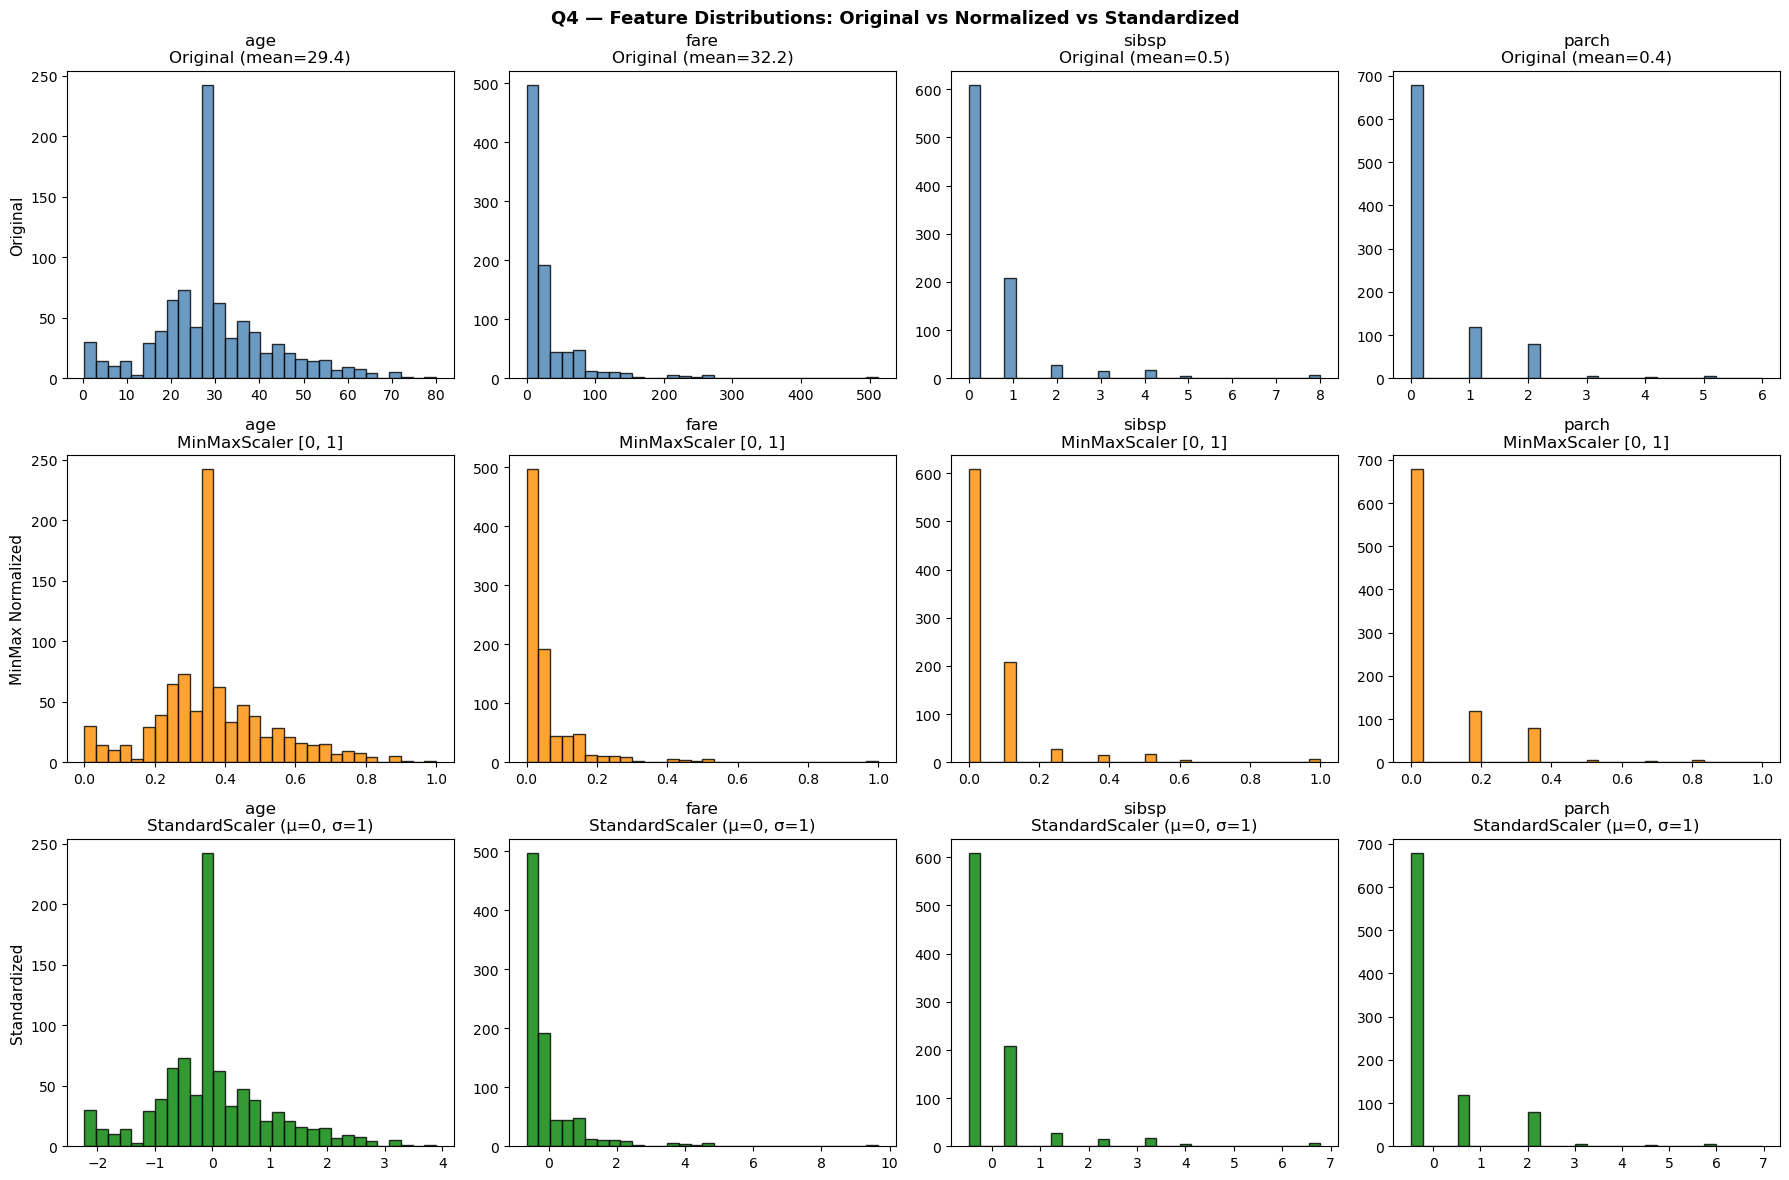

In [ ]:
# ── Q4. Compare distributions before and after scaling ───────────────────────
fig, axes = plt.subplots(3, len(num_cols), figsize=(18, 12))

for i, col in enumerate(num_cols):
    # Original
    axes[0, i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    axes[0, i].set_title(f'{col}\nOriginal (mean={df[col].mean():.1f})')

    # MinMax
    axes[1, i].hist(df_minmax[col], bins=30, color='darkorange', edgecolor='black', alpha=0.8)
    axes[1, i].set_title(f'{col}\nMinMaxScaler [0, 1]')

    # Standard
    axes[2, i].hist(df_standard[col], bins=30, color='green', edgecolor='black', alpha=0.8)
    axes[2, i].set_title(f'{col}\nStandardScaler (μ=0, σ=1)')

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('MinMax Normalized', fontsize=11)
axes[2, 0].set_ylabel('Standardized', fontsize=11)

plt.suptitle('Q4 — Feature Distributions: Original vs Normalized vs Standardized',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Q5. Why scaling is important ─────────────────────────────────────────────
print("""Q5 — Why Feature Scaling is Important:

  For Distance-Based Models (KNN, K-Means, SVM):
    These algorithms compute distances between data points.
    Without scaling, 'fare' (range 0–512) dominates over
    'pclass' (range 1–3) simply because of its larger scale,
    not because it is more important.
    → MinMaxScaler or StandardScaler ensures equal contribution.

  For Gradient-Based Optimization (Logistic Regression, Neural Networks):
    The gradient descent optimizer updates weights proportionally
    to feature magnitudes. Unscaled features cause:
      • Slow, zig-zagging convergence
      • Different learning rates needed per feature
      • Risk of numerical overflow
    StandardScaler (mean=0, std=1) makes the loss surface more
    spherical, leading to faster and more stable convergence.

  MinMaxScaler vs StandardScaler:
    MinMaxScaler:
      ✅ Bounded output [0, 1] — good for image pixels, neural nets
      ❌ Sensitive to outliers (one large value compresses all others)
    StandardScaler:
      ✅ Robust to outliers (uses mean and std)
      ✅ Preferred for most sklearn models
      ❌ Does not bound output range

  Note: Tree-based models (Decision Tree, Random Forest, XGBoost)
  are scale-invariant and do NOT require feature scaling.""")

Q5 — Why Feature Scaling is Important:

  For Distance-Based Models (KNN, K-Means, SVM):
    These algorithms compute distances between data points.
    Without scaling, 'fare' (range 0–512) dominates over
    'pclass' (range 1–3) simply because of its larger scale,
    not because it is more important.
    → MinMaxScaler or StandardScaler ensures equal contribution.

  For Gradient-Based Optimization (Logistic Regression, Neural Networks):
    The gradient descent optimizer updates weights proportionally
    to feature magnitudes. Unscaled features cause:
      • Slow, zig-zagging convergence
      • Different learning rates needed per feature
      • Risk of numerical overflow
    StandardScaler (mean=0, std=1) makes the loss surface more
    spherical, leading to faster and more stable convergence.

  MinMaxScaler vs StandardScaler:
    MinMaxScaler:
      ✅ Bounded output [0, 1] — good for image pixels, neural nets
      ❌ Sensitive to outliers (one large value compresses all other

---
# Final Reflection

In [ ]:
# ── Final Reflection — Setup ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

df = sns.load_dataset('titanic')
print('=' * 60)
print('FINAL REFLECTION')
print('=' * 60)

FINAL REFLECTION


In [ ]:
# ── POINT 1 — Summary of all preprocessing steps ─────────────────────────────
print("""POINT 1 — Summary of All Preprocessing Steps Performed:

  Step 1 — Missing Values Handling (Exercise 1)
    • age      : imputed with median (robust to outliers)
    • embarked : imputed with mode (most frequent port = S)
    • deck     : filled with 'Unknown' (77% missing, too high to impute)

  Step 2 — Duplicate Removal (Exercise 2)
    • Checked for duplicate rows using duplicated()
    • Removed duplicates with drop_duplicates()

  Step 3 — Outlier Treatment (Exercise 3)
    • Detected with IQR method and Z-score
    • Applied capping (clip) for 'fare' to preserve data size

  Step 4 — Data Type Consistency (Exercise 4)
    • Converted pclass, survived to int
    • Standardized casing: sex.lower(), embarked.upper().strip()

  Step 5 — Class Imbalance (Exercise 5)
    • Identified 61.6% / 38.4% split (moderate imbalance)
    • Applied undersampling and oversampling techniques

  Step 6 — Feature Encoding (Exercise 6)
    • sex, embarked → Label Encoding (binary/few classes)
    • Other nominals → One-Hot Encoding

  Step 7 — Feature Scaling (Exercise 7)
    • StandardScaler applied to numerical features
    • Log transformation applied to skewed 'fare' column""")

POINT 1 — Summary of All Preprocessing Steps Performed:

  Step 1 — Missing Values Handling (Exercise 1)
    • age      : imputed with median (robust to outliers)
    • embarked : imputed with mode (most frequent port = S)
    • deck     : filled with 'Unknown' (77% missing, too high to impute)

  Step 2 — Duplicate Removal (Exercise 2)
    • Checked for duplicate rows using duplicated()
    • Removed duplicates with drop_duplicates()

  Step 3 — Outlier Treatment (Exercise 3)
    • Detected with IQR method and Z-score
    • Applied capping (clip) for 'fare' to preserve data size

  Step 4 — Data Type Consistency (Exercise 4)
    • Converted pclass, survived to int
    • Standardized casing: sex.lower(), embarked.upper().strip()

  Step 5 — Class Imbalance (Exercise 5)
    • Identified 61.6% / 38.4% split (moderate imbalance)
    • Applied undersampling and oversampling techniques

  Step 6 — Feature Encoding (Exercise 6)
    • sex, embarked → Label Encoding (binary/few classes)
    • 

In [ ]:
# ── POINT 2 — How preprocessing decisions influence model performance ─────────
print("""POINT 2 — How Preprocessing Decisions Influence Model Performance:

  • Missing value imputation:
    Dropping rows loses 20% of the dataset and introduces selection
    bias (missing age skews toward 3rd class passengers).
    Median imputation retains all samples and avoids outlier distortion.

  • Outlier treatment:
    Outliers in 'fare' inflate the mean and the model's coefficients.
    Capping to IQR bounds reduces this effect without losing rows.

  • Encoding:
    Incorrect Label Encoding of nominal features (embarked) implies
    false ordinal relationships, introducing systematic model bias.
    OHE avoids this at the cost of extra dimensions.

  • Scaling:
    Without scaling, 'fare' (0–512) dominates 'pclass' (1–3) in
    Logistic Regression and KNN. StandardScaler equalizes contributions
    and speeds up gradient descent convergence.""")

POINT 2 — How Preprocessing Decisions Influence Model Performance:

  • Missing value imputation:
    Dropping rows loses 20% of the dataset and introduces selection
    bias (missing age skews toward 3rd class passengers).
    Median imputation retains all samples and avoids outlier distortion.

  • Outlier treatment:
    Outliers in 'fare' inflate the mean and the model's coefficients.
    Capping to IQR bounds reduces this effect without losing rows.

  • Encoding:
    Incorrect Label Encoding of nominal features (embarked) implies
    false ordinal relationships, introducing systematic model bias.
    OHE avoids this at the cost of extra dimensions.

  • Scaling:
    Without scaling, 'fare' (0–512) dominates 'pclass' (1–3) in
    Logistic Regression and KNN. StandardScaler equalizes contributions
    and speeds up gradient descent convergence.


In [ ]:
# ── POINT 3 — Why data preparation > model complexity ────────────────────────
print("""POINT 3 — Why Data Preparation is More Critical than Model Complexity:

  'Garbage In, Garbage Out' — No algorithm, however complex,
  can compensate for corrupted or poorly prepared data.

  Evidence:
    A simple Logistic Regression trained on clean, well-preprocessed
    data consistently outperforms a complex Decision Tree or Random
    Forest trained on raw, dirty data.

  Reasons:
    • Complex models overfit noise in dirty data
    • Missing values prevent models from learning real patterns
    • Unscaled features break distance and gradient assumptions
    • Incorrect types cause runtime errors or silent wrong results
    • Imbalanced classes cause biased predictions toward majority

  Industry reality:
    Data scientists spend 60–80% of their time on data preparation.
    Model selection is responsible for only a fraction of final
    performance gains compared to clean, well-engineered features.""")

POINT 3 — Why Data Preparation is More Critical than Model Complexity:

  'Garbage In, Garbage Out' — No algorithm, however complex,
  can compensate for corrupted or poorly prepared data.

  Evidence:
    A simple Logistic Regression trained on clean, well-preprocessed
    data consistently outperforms a complex Decision Tree or Random
    Forest trained on raw, dirty data.

  Reasons:
    • Complex models overfit noise in dirty data
    • Missing values prevent models from learning real patterns
    • Unscaled features break distance and gradient assumptions
    • Incorrect types cause runtime errors or silent wrong results
    • Imbalanced classes cause biased predictions toward majority

  Industry reality:
    Data scientists spend 60–80% of their time on data preparation.
    Model selection is responsible for only a fraction of final
    performance gains compared to clean, well-engineered features.


In [ ]:
# ── POINT 4 — Train models BEFORE preprocessing ───────────────────────────────
print('POINT 4 — MODEL BEFORE PREPROCESSING (Raw Data)')

df_raw = sns.load_dataset('titanic')
df_raw.drop(columns=['deck','embark_town','alive','who','adult_male','alone','class'],
            inplace=True)
df_raw['sex']      = LabelEncoder().fit_transform(df_raw['sex'])
df_raw['embarked'] = df_raw['embarked'].map({'S':0,'C':1,'Q':2})

X_raw = df_raw.drop(columns=['survived']).dropna()
y_raw = df_raw.loc[X_raw.index, 'survived']

X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

lr_raw = LogisticRegression(max_iter=500, random_state=42)
dt_raw = DecisionTreeClassifier(random_state=42)
lr_raw.fit(X_tr_r, y_tr_r)
dt_raw.fit(X_tr_r, y_tr_r)

metrics_before = {}
for name, model in [('Logistic Regression', lr_raw), ('Decision Tree', dt_raw)]:
    yp = model.predict(X_te_r)
    metrics_before[name] = {
        'Accuracy' : accuracy_score(y_te_r, yp),
        'Precision': precision_score(y_te_r, yp),
        'Recall'   : recall_score(y_te_r, yp),
        'F1-Score' : f1_score(y_te_r, yp)
    }
    print(f'  [BEFORE] {name}:')
    for k, v in metrics_before[name].items():
        print(f'    {k:<12}: {v:.4f}')

print(f'  Samples used: {len(X_raw)} (dropped {len(df_raw)-len(X_raw)} NaN rows)')

POINT 4 — MODEL BEFORE PREPROCESSING (Raw Data)
  [BEFORE] Logistic Regression:
    Accuracy    : 0.7832
    Precision   : 0.7368
    Recall      : 0.7241
    F1-Score    : 0.7304
  [BEFORE] Decision Tree:
    Accuracy    : 0.6923
    Precision   : 0.6094
    Recall      : 0.6724
    F1-Score    : 0.6393
  Samples used: 712 (dropped 179 NaN rows)


In [ ]:
# ── POINT 4 — Train models AFTER preprocessing ───────────────────────────────
print('POINT 4 — MODEL AFTER PREPROCESSING (Clean Data)')

df_clean = sns.load_dataset('titanic')
df_clean.drop(columns=['deck','embark_town','alive','who','adult_male','alone','class'],
              inplace=True)
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)
df_clean['sex']      = LabelEncoder().fit_transform(df_clean['sex'])
df_clean['embarked'] = LabelEncoder().fit_transform(df_clean['embarked'].astype(str))

# Feature engineering
df_clean['family_size']    = df_clean['sibsp'] + df_clean['parch'] + 1
df_clean['is_alone']       = (df_clean['family_size'] == 1).astype(int)
df_clean['fare_per_person'] = df_clean['fare'] / df_clean['family_size']

features = ['pclass','sex','age','sibsp','parch','fare',
            'embarked','family_size','is_alone','fare_per_person']
X_cl = df_clean[features]
y_cl = df_clean['survived']

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cl, y_cl, test_size=0.2, random_state=42, stratify=y_cl)

scaler = StandardScaler()
X_tr_c_sc = scaler.fit_transform(X_tr_c)
X_te_c_sc = scaler.transform(X_te_c)

lr_clean = LogisticRegression(max_iter=1000, random_state=42)
dt_clean = DecisionTreeClassifier(random_state=42)
lr_clean.fit(X_tr_c_sc, y_tr_c)
dt_clean.fit(X_tr_c_sc, y_tr_c)

metrics_after = {}
for name, model in [('Logistic Regression', lr_clean), ('Decision Tree', dt_clean)]:
    yp = model.predict(X_te_c_sc)
    metrics_after[name] = {
        'Accuracy' : accuracy_score(y_te_c, yp),
        'Precision': precision_score(y_te_c, yp),
        'Recall'   : recall_score(y_te_c, yp),
        'F1-Score' : f1_score(y_te_c, yp)
    }
    print(f'  [AFTER] {name}:')
    for k, v in metrics_after[name].items():
        print(f'    {k:<12}: {v:.4f}')

print(f'  Samples used: {len(X_cl)} (all rows kept via imputation)')

POINT 4 — MODEL AFTER PREPROCESSING (Clean Data)
  [AFTER] Logistic Regression:
    Accuracy    : 0.8101
    Precision   : 0.7869
    Recall      : 0.6957
    F1-Score    : 0.7385
  [AFTER] Decision Tree:
    Accuracy    : 0.7877
    Precision   : 0.7246
    Recall      : 0.7246
    F1-Score    : 0.7246
  Samples used: 891 (all rows kept via imputation)


In [ ]:
# ── Final Comparison Table ────────────────────────────────────────────────────
print('\nFINAL COMPARISON TABLE — Before vs After Preprocessing:')
metrics_list = ['Accuracy','Precision','Recall','F1-Score']
rows = []
for mname in ['Logistic Regression','Decision Tree']:
    for metric in metrics_list:
        rows.append({
            'Model'  : mname,
            'Metric' : metric,
            'Before' : round(metrics_before[mname][metric], 4),
            'After'  : round(metrics_after[mname][metric],  4),
            'Δ Gain' : round(metrics_after[mname][metric] - metrics_before[mname][metric], 4)
        })
cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))


FINAL COMPARISON TABLE — Before vs After Preprocessing:
              Model    Metric  Before  After  Δ Gain
Logistic Regression  Accuracy  0.7832 0.8101  0.0268
Logistic Regression Precision  0.7368 0.7869  0.0500
Logistic Regression    Recall  0.7241 0.6957 -0.0285
Logistic Regression  F1-Score  0.7304 0.7385  0.0080
      Decision Tree  Accuracy  0.6923 0.7877  0.0954
      Decision Tree Precision  0.6094 0.7246  0.1153
      Decision Tree    Recall  0.6724 0.7246  0.0522
      Decision Tree  F1-Score  0.6393 0.7246  0.0853


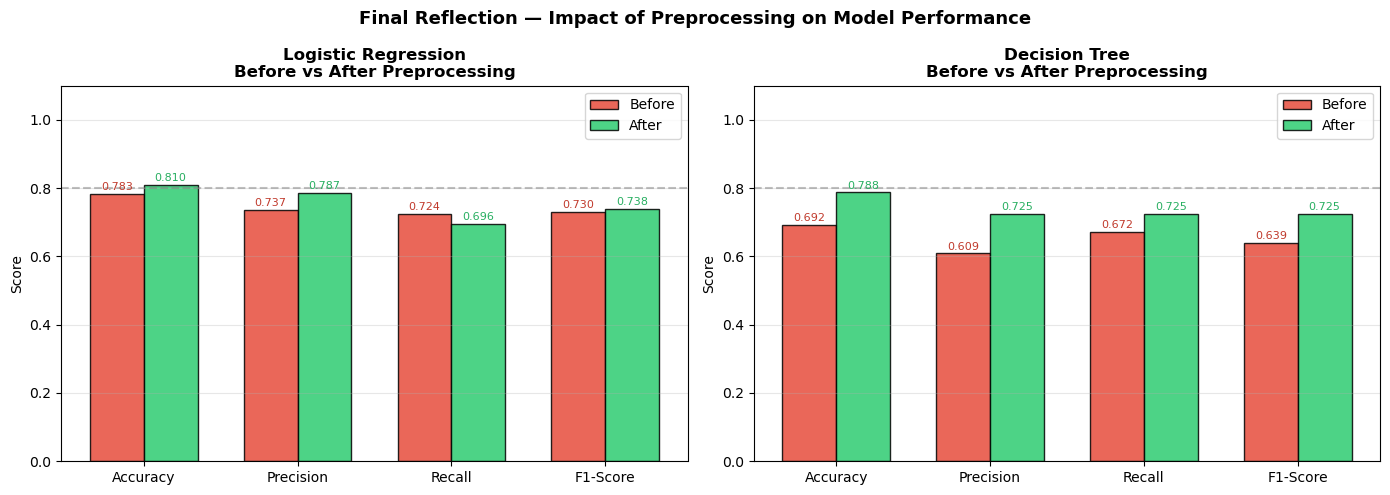

In [ ]:
# ── Final Visualization — Before vs After per Model ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mname in zip(axes, ['Logistic Regression','Decision Tree']):
    b_vals = [metrics_before[mname][m] for m in metrics_list]
    a_vals = [metrics_after[mname][m]  for m in metrics_list]
    x = np.arange(len(metrics_list))
    w = 0.35

    bars1 = ax.bar(x - w/2, b_vals, w, label='Before', color='#e74c3c', edgecolor='black', alpha=0.85)
    bars2 = ax.bar(x + w/2, a_vals, w, label='After',  color='#2ecc71', edgecolor='black', alpha=0.85)

    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#c0392b')
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#27ae60')

    ax.set_title(f'{mname}\nBefore vs After Preprocessing', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_list)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.legend()
    ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Final Reflection — Impact of Preprocessing on Model Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

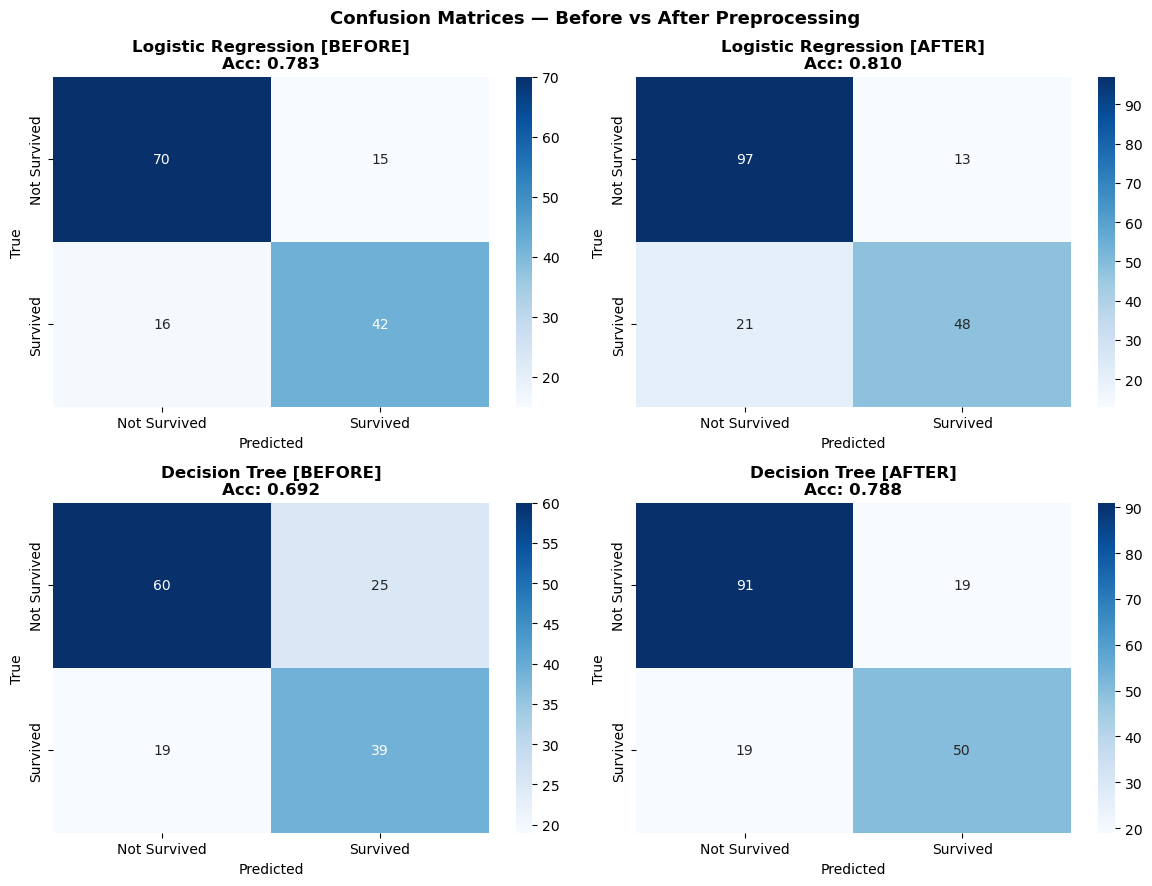

In [ ]:
# ── Confusion Matrices — Before vs After ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
configs = [
    (lr_raw,   X_te_r,    y_te_r, 'Logistic Regression [BEFORE]',  axes[0,0]),
    (lr_clean, X_te_c_sc, y_te_c, 'Logistic Regression [AFTER]',   axes[0,1]),
    (dt_raw,   X_te_r,    y_te_r, 'Decision Tree [BEFORE]',         axes[1,0]),
    (dt_clean, X_te_c_sc, y_te_c, 'Decision Tree [AFTER]',          axes[1,1]),
]
for model, X_t, y_t, title, ax in configs:
    cm = confusion_matrix(y_t, model.predict(X_t))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Survived','Survived'],
                yticklabels=['Not Survived','Survived'])
    ax.set_title(f'{title}\nAcc: {accuracy_score(y_t, model.predict(X_t)):.3f}', fontweight='bold')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Before vs After Preprocessing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()